### 統計分析協助結構化醫療書具的MLI流程
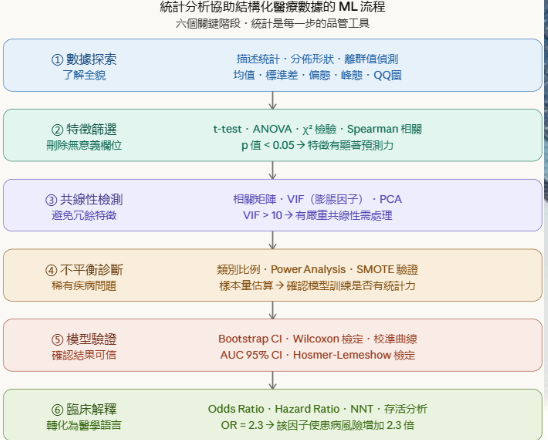

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("whenamancodes/predict-diabities")

print("Path to dataset files:", path)

100%|██████████| 8.91k/8.91k [00:00<00:00, 4.99MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/whenamancodes/predict-diabities/versions/1


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

path = kagglehub.dataset_download("whenamancodes/predict-diabities")
files = [f for f in os.listdir(path) if f.endswith('.csv')]
df = pd.read_csv(os.path.join(path, files[0]))

cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

print("資料筆數：", df.shape)
display(df.head())

Using Colab cache for faster access to the 'predict-diabities' dataset.
資料筆數： (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


### **階段一** : **數據探索**

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,121.66,72.39,29.11,140.67,32.46,0.47,33.24,0.35
std,3.37,30.44,12.10,8.79,86.38,6.88,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,14.00,18.20,0.08,21.00,0.00
25%,1.00,99.75,64.00,25.00,121.50,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,29.00,125.00,32.30,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


BMI        -> 偏態: 0.60, 峰態: 0.91
Glucose    -> 偏態: 0.53, 峰態: -0.26
Age        -> 偏態: 1.13, 峰態: 0.63


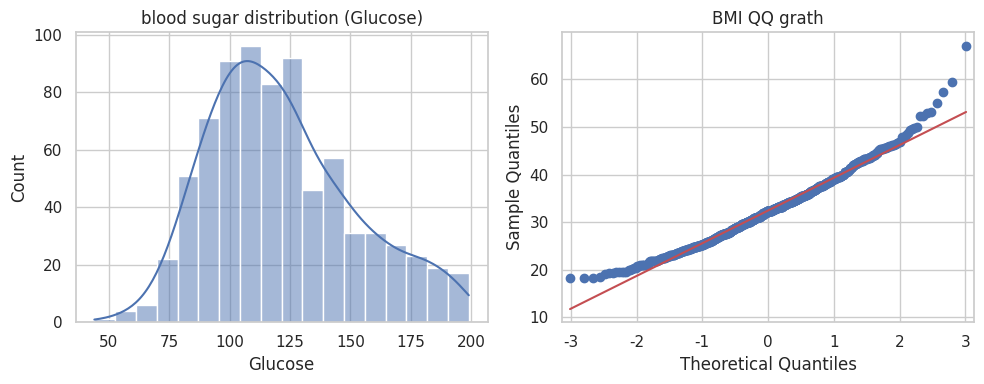

In [22]:
from scipy import stats
import statsmodels.api as sm
summary = df.describe().round(2)
display(summary)

for col in ['BMI', 'Glucose', 'Age']:
    skew = stats.skew(df[col])
    kurt = stats.kurtosis(df[col])
    print(f"{col:10} -> 偏態: {skew:.2f}, 峰態: {kurt:.2f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Glucose'], kde=True)
plt.title('blood sugar distribution (Glucose)')

plt.subplot(1, 2, 2)
sm.qqplot(df['BMI'], line='s', ax=plt.gca())
plt.title('BMI QQ grath')
plt.tight_layout()
plt.show()

### **階段二** : 特徵篩選

In [23]:
target = 'Outcome'
features = df.columns.drop(target)
selected_features = []

for col in features:
    group1 = df[df[target] == 1][col]
    group0 = df[df[target] == 0][col]
    t_stat, p_val = stats.ttest_ind(group1, group0)

    if p_val < 0.05:
        selected_features.append(col)
        print(f"✅ 保留 {col:20} (p={p_val:.4f})")
    else:
        print(f"❌ 去除 {col:20} (p={p_val:.4f})")

✅ 保留 Pregnancies          (p=0.0000)
✅ 保留 Glucose              (p=0.0000)
✅ 保留 BloodPressure        (p=0.0000)
✅ 保留 SkinThickness        (p=0.0000)
✅ 保留 Insulin              (p=0.0000)
✅ 保留 BMI                  (p=0.0000)
✅ 保留 DiabetesPedigreeFunction (p=0.0000)
✅ 保留 Age                  (p=0.0000)


### **階段三** : 共線性檢測

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif = df[selected_features].assign(const=1)
vif_df = pd.DataFrame()
vif_df["Feature"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

vif_results = vif_df[vif_df['Feature'] != 'const']
display(vif_results)

final_features = vif_results[vif_results['VIF'] <= 10]['Feature'].tolist()
print("\n✨ 最終模型入選特徵:", final_features)

,Feature,VIF
0,Pregnancies,1.430466
1,Glucose,1.361314
2,BloodPressure,1.242670
3,SkinThickness,1.451029
4,Insulin,1.239392
5,BMI,1.572588
6,DiabetesPedigreeFunction,1.048391
7,Age,1.616142



✨ 最終模型入選特徵: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


### **階段四** : 不平衡診斷

In [19]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X = df[final_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("原始類別比例:\n", y_train.value_counts(normalize=True).round(2))

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("\nSMOTE 後類別比例:\n", y_train_res.value_counts(normalize=True).round(2))

原始類別比例:
 Outcome
0    0.65
1    0.35
Name: proportion, dtype: float64

SMOTE 後類別比例:
 Outcome
0    0.5
1    0.5
Name: proportion, dtype: float64


### **階段五** : 模型驗證

🎯 模型 AUC: 0.809
📊 AUC 95% CI: [0.741 - 0.867]


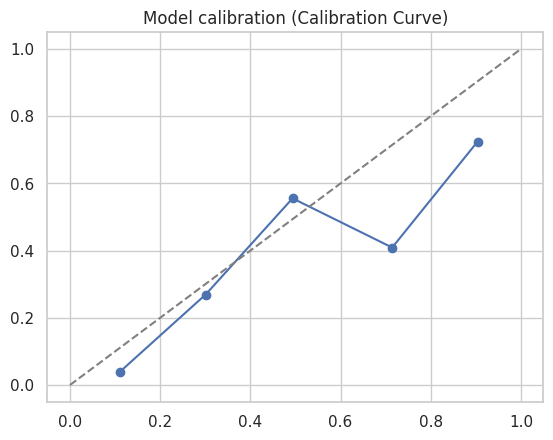

In [24]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_res, y_train_res)

y_probs = model.predict_proba(X_test)[:, 1]

n_bootstraps = 1000
rng_seed = 42
bootstrapped_aucs = []

for i in range(n_bootstraps):
    indices = np.random.RandomState(rng_seed + i).randint(0, len(y_test), len(y_test))
    if len(np.unique(y_test.iloc[indices])) < 2: continue
    bootstrapped_aucs.append(roc_auc_score(y_test.iloc[indices], y_probs[indices]))

print(f"🎯 模型 AUC: {roc_auc_score(y_test, y_probs):.3f}")
print(f"📊 AUC 95% CI: [{np.percentile(bootstrapped_aucs, 2.5):.3f} - {np.percentile(bootstrapped_aucs, 97.5):.3f}]")


prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=5)
plt.plot(prob_pred, prob_true, marker='o', label='Logistic Regression')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Model calibration (Calibration Curve)')
plt.show()

### **階段六** : 臨床解釋

In [25]:
or_values = np.exp(model.coef_[0])
interpretation = pd.DataFrame({'Feature': final_features, 'Odds Ratio': or_values})

for _, row in interpretation.iterrows():
    direction = "增加" if row['Odds Ratio'] > 1 else "降低"
    percent = abs(row['Odds Ratio'] - 1) * 100
    print(f"📌 {row['Feature']}: OR = {row['Odds Ratio']:.2f}")
    print(f"   該因子每上升 1 單位，患病風險將{direction} {percent:.1f}%。")

📌 Pregnancies: OR = 1.08
   該因子每上升 1 單位，患病風險將增加 8.3%。
📌 Glucose: OR = 1.04
   該因子每上升 1 單位，患病風險將增加 4.1%。
📌 BloodPressure: OR = 1.00
   該因子每上升 1 單位，患病風險將降低 0.2%。
📌 SkinThickness: OR = 1.00
   該因子每上升 1 單位，患病風險將增加 0.1%。
📌 Insulin: OR = 1.00
   該因子每上升 1 單位，患病風險將降低 0.1%。
📌 BMI: OR = 1.12
   該因子每上升 1 單位，患病風險將增加 12.0%。
📌 DiabetesPedigreeFunction: OR = 2.15
   該因子每上升 1 單位，患病風險將增加 115.3%。
📌 Age: OR = 1.02
   該因子每上升 1 單位，患病風險將增加 1.5%。
